# Portfolio Part 4 - Analysis of Airlines Delay

Name: Chayut Deekongsieng\
ID: 46800883


## Dataset Background

The dataset from the U.S. Department of Transportation's (DOT) Bureau of Transportation Statistics (BTS) records the on-time performance of domestic flights operated by major U.S. air carriers in 2008. It includes detailed information on the number of on-time, delayed, canceled, and diverted flights, along with the causes of any delays, cancellations, or diversions. This data is typically summarized in DOT’s monthly Air Travel Consumer Report.

Given the original dataset contains up to 1,936,758 internal U.S. flights for the year, I have selected a random 5% sample using the sample() method, reducing the dataset to 96,838 entries. This smaller sample is more suitable for analysis within the scope of this portfolio assignment, while still retaining a representative subset of the larger data.

This dataset is composed by the following variables:
- Year 2008
- Month 1-12 
- DayofMonth 1-31
- DayOfWeek 1 (Monday) - 7 (Sunday)
- DepTime actual departure time (local, hhmm)
- CRSDepTime scheduled departure time (local, hhmm)
- ArrTime actual arrival time (local, hhmm)
- CRSArrTime scheduled arrival time (local, hhmm)
- UniqueCarrier unique carrier code
- FlightNum flight number
- TailNum plane tail number: aircraft registration, unique aircraft identifier
- ActualElapsedTime in minutes
- CRSElapsedTime in minutes
- AirTime in minutes
- ArrDelay arrival delay, in minutes: A flight is counted as "on time" if it operated less than 15 minutes later the scheduled time shown in the carriers' Computerized Reservations Systems (CRS).
- DepDelay departure delay, in minutes
- Origin origin IATA airport code
- Dest destination IATA airport code
- Distance in miles
- TaxiIn taxi in time, in minutes
- TaxiOut taxi out time in minutes
- Cancelled *was the flight cancelled
- CancellationCode reason for cancellation (A = carrier, B = weather, C = NAS, D = security)
- Diverted 1 = yes, 0 = no
- CarrierDelay in minutes: Carrier delay is within the control of the air carrier. Examples of occurrences that may determine carrier delay are: aircraft cleaning, aircraft damage, awaiting the arrival of connecting passengers or crew, baggage, bird strike, cargo loading, catering, computer, outage-carrier equipment, crew legality (pilot or attendant rest), damage by hazardous goods, engineering inspection, fueling, handling disabled passengers, late crew, lavatory servicing, maintenance, oversales, potable water servicing, removal of unruly passenger, slow boarding or seating, stowing carry-on baggage, weight and balance delays.
- WeatherDelay in minutes: Weather delay is caused by extreme or hazardous weather conditions that are forecasted or manifest themselves on point of departure, enroute, or on point of arrival.
- NASDelay in minutes: Delay that is within the control of the National Airspace System (NAS) may include: non-extreme weather conditions, airport operations, heavy traffic volume, air traffic control, etc.
- SecurityDelay in minutes: Security delay is caused by evacuation of a terminal or concourse, re-boarding of aircraft because of security breach, inoperative screening equipment and/or long lines in excess of 29 minutes at screening areas.
- LateAircraftDelay in minutes: Arrival delay at an airport due to the late arrival of the same aircraft at a previous airport. The ripple effect of an earlier delay at downstream airports is referred to as delay propagation

## Objective of Analysis

Before conducting exploratory data analysis, my main objective was to identify the features that impact overall delay times. Additionally, I aimed to predict both the arrival delay time and the flight status before the flight had departed. This would provide insights into the factors contributing to delays and help anticipate flight outcomes, allowing for better decision-making and operational improvements.

I hypothesize that certain factors—such as departure delays, taxi-out time, and carrier type—are strong predictors of arrival delays. I also expect that by analyzing these features, we can accurately predict whether a flight will be on-time, delayed, canceled, or diverted.

### Import libraries and load dataset

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore') #ignore the warning
import seaborn as sns

Read and load 'DelayedFlights' dataset to pandas dataframe named 'df'

In [10]:
df = pd.read_csv('DelayedFlights.csv')

#examine first 5 rows of dataset
df.head()

,id,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,6583804,2008,12,6,6,1805,1755,2146.0,2035,YV,...,5.0,99.0,0,N,0,71.0,0.0,0.0,0.0,0.0
1,1604365,2008,3,23,7,2120,1200,2241.0,1333,NW,...,7.0,19.0,0,N,0,543.0,0.0,0.0,0.0,5.0
2,1395655,2008,3,31,1,1731,1710,1819.0,1810,OO,...,3.0,1.0,0,N,0,NaN,NaN,NaN,NaN,NaN
3,178786,2008,1,6,7,1507,1413,1601.0,1509,OO,...,5.0,17.0,0,N,0,0.0,0.0,0.0,0.0,52.0
4,2972767,2008,5,22,4,637,630,812.0,750,CO,...,5.0,16.0,0,N,0,0.0,0.0,15.0,7.0,0.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96838 entries, 0 to 96837
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 96838 non-null  int64  
 1   Year               96838 non-null  int64  
 2   Month              96838 non-null  int64  
 3   DayofMonth         96838 non-null  int64  
 4   DayOfWeek          96838 non-null  int64  
 5   DepTime            96838 non-null  int64  
 6   CRSDepTime         96838 non-null  int64  
 7   ArrTime            96487 non-null  float64
 8   CRSArrTime         96838 non-null  int64  
 9   UniqueCarrier      96838 non-null  object 
 10  FlightNum          96838 non-null  int64  
 11  TailNum            96838 non-null  object 
 12  ActualElapsedTime  96421 non-null  float64
 13  CRSElapsedTime     96831 non-null  float64
 14  AirTime            96421 non-null  float64
 15  ArrDelay           96421 non-null  float64
 16  DepDelay           968

In [12]:
print('Shape of dataset', df.shape)

Shape of dataset (96838, 30)


Rename the column to improve clarity and align with a more familiar format.

In [14]:
new_col_names = ['id', 'year', 'month', 'day_of_month', 'day_of_week', 'departure_time', 
                'scheduled_departure_time', 'arrival_time', 'scheduled_arrival_time', 
                'carrier_code', 'flight_no', 'tail_no', 'actual_elapsed_time_min', 
                'estimated_elapsed_time_min', 'air_time_min', 'arrival_delay_min', 
                'departure_delay_min', 'origin', 'destination', 'distance_mi', 'taxi_in_min', 
                'taxi_out_min', 'cancelled', 'cancellation_code', 'diverted', 
                'carrier_delay_min', 'weather_delay_min', 'nas_delay_min', 'security_delay_min', 
                'late_aircraft_delay_min']

# assign to datafram column name
df.columns = new_col_names

## 1) Data Preparation

### Handle the missing values

In [17]:
# Display count of missing values for each column
missing_count = df.isnull().sum()
missing_count

id                                0
year                              0
month                             0
day_of_month                      0
day_of_week                       0
departure_time                    0
scheduled_departure_time          0
arrival_time                    351
scheduled_arrival_time            0
carrier_code                      0
flight_no                         0
tail_no                           0
actual_elapsed_time_min         417
estimated_elapsed_time_min        7
air_time_min                    417
arrival_delay_min               417
departure_delay_min               0
origin                            0
destination                       0
distance_mi                       0
taxi_in_min                     351
taxi_out_min                     30
cancelled                         0
cancellation_code                 0
diverted                          0
carrier_delay_min             34326
weather_delay_min             34326
nas_delay_min               

There are missing values as follows:

- 417 missing values in 'actual_elapsed_time_min ', 'air_time_min ', and 'arrival_delay_min  '
- 351 missing values in 'arrival_time ' and 'taxi_in_min'
- 30 missing values in 'taxi_out_min'
- 7 missing values in estimated_elapsed_time_min 
- 34326 missing values in 'carrier_delay_min ', 'weather_delay_min', 'nas_delay_min ', 'security_delay_min', and 'late_aircraft_delay_min'

Since variables with the same number of missing values probably have the same reason, we can handle them using the same method.

In [19]:
# Displaying the row with missing 'AirTime'
missing_airTime = df[df['air_time_min'].isnull()]
missing_airTime

,id,year,month,day_of_month,day_of_week,departure_time,scheduled_departure_time,arrival_time,scheduled_arrival_time,carrier_code,...,taxi_in_min,taxi_out_min,cancelled,cancellation_code,diverted,carrier_delay_min,weather_delay_min,nas_delay_min,security_delay_min,late_aircraft_delay_min
233,1078538,2008,2,5,2,1331,1310,NaN,1555,AA,...,NaN,21.0,0,N,1,NaN,NaN,NaN,NaN,NaN
343,6749711,2008,12,24,3,1905,1855,141.0,2300,DL,...,8.0,117.0,0,N,1,NaN,NaN,NaN,NaN,NaN
394,3545882,2008,6,16,1,1404,1355,NaN,1534,B6,...,NaN,27.0,0,N,1,NaN,NaN,NaN,NaN,NaN
772,1577057,2008,3,7,5,1028,720,NaN,830,MQ,...,NaN,15.0,0,N,1,NaN,NaN,NaN,NaN,NaN
913,6279793,2008,11,23,7,926,745,NaN,845,MQ,...,NaN,9.0,1,B,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94888,3549244,2008,6,22,7,1013,935,NaN,1806,B6,...,NaN,12.0,0,N,1,NaN,NaN,NaN,NaN,NaN
95533,5013192,2008,9,14,7,1832,1805,NaN,2030,OO,...,NaN,11.0,0,N,1,NaN,NaN,NaN,NaN,NaN
95877,4677118,2008,8,15,5,1455,1308,NaN,1700,NW,...,NaN,39.0,0,N,1,NaN,NaN,NaN,NaN,NaN
95906,6742459,2008,12,18,4,1903,1855,104.0,2300,DL,...,8.0,42.0,0,N,1,NaN,NaN,NaN,NaN,NaN


In [20]:
missing_arrival_time = df[df['arrival_time'].isnull()]
missing_arrival_time

,id,year,month,day_of_month,day_of_week,departure_time,scheduled_departure_time,arrival_time,scheduled_arrival_time,carrier_code,...,taxi_in_min,taxi_out_min,cancelled,cancellation_code,diverted,carrier_delay_min,weather_delay_min,nas_delay_min,security_delay_min,late_aircraft_delay_min
233,1078538,2008,2,5,2,1331,1310,NaN,1555,AA,...,NaN,21.0,0,N,1,NaN,NaN,NaN,NaN,NaN
394,3545882,2008,6,16,1,1404,1355,NaN,1534,B6,...,NaN,27.0,0,N,1,NaN,NaN,NaN,NaN,NaN
772,1577057,2008,3,7,5,1028,720,NaN,830,MQ,...,NaN,15.0,0,N,1,NaN,NaN,NaN,NaN,NaN
913,6279793,2008,11,23,7,926,745,NaN,845,MQ,...,NaN,9.0,1,B,0,NaN,NaN,NaN,NaN,NaN
1295,682741,2008,2,26,2,2102,1955,NaN,2235,WN,...,NaN,21.0,0,N,1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94804,4804801,2008,8,13,3,1737,1725,NaN,2142,CO,...,NaN,17.0,0,N,1,NaN,NaN,NaN,NaN,NaN
94888,3549244,2008,6,22,7,1013,935,NaN,1806,B6,...,NaN,12.0,0,N,1,NaN,NaN,NaN,NaN,NaN
95533,5013192,2008,9,14,7,1832,1805,NaN,2030,OO,...,NaN,11.0,0,N,1,NaN,NaN,NaN,NaN,NaN
95877,4677118,2008,8,15,5,1455,1308,NaN,1700,NW,...,NaN,39.0,0,N,1,NaN,NaN,NaN,NaN,NaN


In [21]:
missing_taxiIn = df[df['taxi_in_min'].isnull()]
missing_taxiIn

,id,year,month,day_of_month,day_of_week,departure_time,scheduled_departure_time,arrival_time,scheduled_arrival_time,carrier_code,...,taxi_in_min,taxi_out_min,cancelled,cancellation_code,diverted,carrier_delay_min,weather_delay_min,nas_delay_min,security_delay_min,late_aircraft_delay_min
233,1078538,2008,2,5,2,1331,1310,NaN,1555,AA,...,NaN,21.0,0,N,1,NaN,NaN,NaN,NaN,NaN
394,3545882,2008,6,16,1,1404,1355,NaN,1534,B6,...,NaN,27.0,0,N,1,NaN,NaN,NaN,NaN,NaN
772,1577057,2008,3,7,5,1028,720,NaN,830,MQ,...,NaN,15.0,0,N,1,NaN,NaN,NaN,NaN,NaN
913,6279793,2008,11,23,7,926,745,NaN,845,MQ,...,NaN,9.0,1,B,0,NaN,NaN,NaN,NaN,NaN
1295,682741,2008,2,26,2,2102,1955,NaN,2235,WN,...,NaN,21.0,0,N,1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94804,4804801,2008,8,13,3,1737,1725,NaN,2142,CO,...,NaN,17.0,0,N,1,NaN,NaN,NaN,NaN,NaN
94888,3549244,2008,6,22,7,1013,935,NaN,1806,B6,...,NaN,12.0,0,N,1,NaN,NaN,NaN,NaN,NaN
95533,5013192,2008,9,14,7,1832,1805,NaN,2030,OO,...,NaN,11.0,0,N,1,NaN,NaN,NaN,NaN,NaN
95877,4677118,2008,8,15,5,1455,1308,NaN,1700,NW,...,NaN,39.0,0,N,1,NaN,NaN,NaN,NaN,NaN


In [22]:
# Count the number of cancelled flights
cancelled_count = (df['cancelled'] == 1).sum()

# Count the number of diverted flights
diverted_count = (df['diverted'] == 1).sum()

print('Total Cancelled Flights: ',cancelled_count)
print('Total Diverted Flights: ',diverted_count)
print('Number of Cancelled or Diverted Flight: ',cancelled_count+diverted_count)

Total Cancelled Flights:  39
Total Diverted Flights:  378
Number of Cancelled or Diverted Flight:  417


The missing values of most of columns seem to occur when a flight is either cancelled or diverted to another destination. This is supported by the fact that the number of cancelled or diverted flights matches the number of missing values. So, it seems reasonable to replace this missing values as 0.

In [24]:
missing_cols = ['actual_elapsed_time_min', 'air_time_min', 'arrival_delay_min',
                'arrival_time','taxi_in_min', 'taxi_out_min','estimated_elapsed_time_min']

In [25]:
# Replace missing values with 0 for the cancelled or diverted entries
df.loc[(df['cancelled'] == 1) | (df['diverted'] == 1), missing_cols] = df[missing_cols].fillna(0)

In [26]:
df.isnull().sum()

id                                0
year                              0
month                             0
day_of_month                      0
day_of_week                       0
departure_time                    0
scheduled_departure_time          0
arrival_time                      0
scheduled_arrival_time            0
carrier_code                      0
flight_no                         0
tail_no                           0
actual_elapsed_time_min           0
estimated_elapsed_time_min        0
air_time_min                      0
arrival_delay_min                 0
departure_delay_min               0
origin                            0
destination                       0
distance_mi                       0
taxi_in_min                       0
taxi_out_min                      0
cancelled                         0
cancellation_code                 0
diverted                          0
carrier_delay_min             34326
weather_delay_min             34326
nas_delay_min               

The remaining missing values appear in columns related to delays, meaning if no delay occurred, the value is left as 'NaN'. Therefore, I will also replace these missing values with 0.

In [28]:
# Fill missing values with 0 for multiple columns
df[['carrier_delay_min', 'weather_delay_min', 'nas_delay_min', 'security_delay_min', 'late_aircraft_delay_min']] = df[['carrier_delay_min', 'weather_delay_min', 'nas_delay_min', 'security_delay_min', 'late_aircraft_delay_min']].fillna(0.0)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96838 entries, 0 to 96837
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          96838 non-null  int64  
 1   year                        96838 non-null  int64  
 2   month                       96838 non-null  int64  
 3   day_of_month                96838 non-null  int64  
 4   day_of_week                 96838 non-null  int64  
 5   departure_time              96838 non-null  int64  
 6   scheduled_departure_time    96838 non-null  int64  
 7   arrival_time                96838 non-null  float64
 8   scheduled_arrival_time      96838 non-null  int64  
 9   carrier_code                96838 non-null  object 
 10  flight_no                   96838 non-null  int64  
 11  tail_no                     96838 non-null  object 
 12  actual_elapsed_time_min     96838 non-null  float64
 13  estimated_elapsed_time_min  968

### Checking Categorical attributes 

In [31]:
# Identify the categorical column by excluding 'numeric' type of data
categorical_cols = df.select_dtypes(exclude=['number']).columns
categorical_cols

Index(['carrier_code', 'tail_no', 'origin', 'destination',
       'cancellation_code'],
      dtype='object')

In [32]:
# Displaying and counting the unique values of categorical attributes
for col in categorical_cols:
    unique_vals = df[col].unique()
    unique_count = df[col].nunique()
    print(f"{unique_count} Unique values in '{col}': {unique_vals}\n")

20 Unique values in 'carrier_code': ['YV' 'NW' 'OO' 'CO' 'AA' 'WN' 'XE' 'AS' 'UA' 'EV' '9E' 'FL' 'OH' 'MQ'
 'US' 'B6' 'DL' 'F9' 'HA' 'AQ']

5199 Unique values in 'tail_no': ['N505MJ' 'N777NC' 'N224SW' ... 'N808AL' 'N185DN' 'N866DA']

294 Unique values in 'origin': ['IAD' 'ORD' 'SLC' 'HDN' 'JAX' 'DFW' 'DAL' 'LAX' 'SJC' 'DEN' 'SEA' 'PHL'
 'SFO' 'CVG' 'RSW' 'BOS' 'RIC' 'DAY' 'CID' 'SGF' 'FWA' 'IAH' 'HOU' 'SAV'
 'ANC' 'PHX' 'MDW' 'JFK' 'MSN' 'LIT' 'MIA' 'FLL' 'OAK' 'EWR' 'CAE' 'ATL'
 'PIT' 'LAS' 'BHM' 'MSY' 'CLT' 'STT' 'AVL' 'MCO' 'BDL' 'SBN' 'SAN' 'TPA'
 'ORF' 'CLE' 'OKC' 'LEX' 'SIT' 'PDX' 'PVD' 'CHS' 'ONT' 'SHV' 'SMF' 'STL'
 'DCA' 'TUL' 'MSP' 'HNL' 'FAT' 'LGA' 'DTW' 'BMI' 'BOI' 'SAT' 'PBI' 'TYS'
 'MCI' 'IND' 'ABQ' 'MLU' 'ELM' 'BWI' 'MLI' 'MKE' 'SNA' 'BUR' 'SDF' 'HRL'
 'TUS' 'CPR' 'EYW' 'BUF' 'CMH' 'RDU' 'PHF' 'DLG' 'MHT' 'EVV' 'HPN' 'AUS'
 'VLD' 'LIH' 'AVP' 'RNO' 'HSV' 'CEC' 'SBP' 'JAC' 'BIL' 'GRR' 'GEG' 'BNA'
 'HHH' 'PNS' 'LFT' 'ATW' 'OGG' 'ALB' 'EGE' 'MEM' 'LGB' 'ASE' 'DSM' 'JAN'
 'ICT

### Create 'DepDate' column to show departure date in one pandas datetime format column

In [34]:
df['departure_date'] = pd.to_datetime(df.year*10000+df.month*100+df.day_of_month,format='%Y%m%d')

### Handle the time features attributes
There are four attributes in the HHMM format, which could lead to misleading analysis if treated as numerical values. To address this, I will convert them into a minutes format to represent the number of minutes since the start of the day.

In [36]:
def time_to_minutes(time_str):
    # Ensure the time is in the format HHMM
    time_str = str(int(time_str)).zfill(4)  # Pad with zeroes if needed
    hours = int(time_str[:2])  # First two digits are hours
    minutes = int(time_str[2:])  # Last two digits are minutes
    return hours * 60 + minutes

# Apply to the relevant columns, and 
df['scheduled_departure_time_min'] = df['scheduled_departure_time'].apply(time_to_minutes)
df['scheduled_arrival_time_min'] = df['scheduled_arrival_time'].apply(time_to_minutes)
df['departure_time_min'] = df['departure_time'].apply(time_to_minutes)
df['arrival_time_min'] = df['arrival_time'].apply(time_to_minutes)

### Drop the columns that will not be utilized in Analysis

To simplify the dataframe structure, it may be necessary to drop irrelevant or unnecessary columns. In this case, I believe the columns id and tail_no, which serve as identifiers for transactions and aircraft, can be removed as they do not contribute to the analysis. Additionally, columns containing time data in the 'xxxx' format should also be considered for removal if they are not needed for further analysis.

In [38]:
df.drop(columns=['id', 'flight_no', 'tail_no', 'departure_time', 'scheduled_departure_time', 'arrival_time', 'scheduled_arrival_time'], inplace=True)

In [39]:
df.head()

,year,month,day_of_month,day_of_week,carrier_code,actual_elapsed_time_min,estimated_elapsed_time_min,air_time_min,arrival_delay_min,departure_delay_min,...,carrier_delay_min,weather_delay_min,nas_delay_min,security_delay_min,late_aircraft_delay_min,departure_date,scheduled_departure_time_min,scheduled_arrival_time_min,departure_time_min,arrival_time_min
0,2008,12,6,6,YV,281.0,220.0,177.0,71.0,10,...,71.0,0.0,0.0,0.0,0.0,2008-12-06,1075,1235,1085,1306
1,2008,3,23,7,NW,81.0,93.0,55.0,548.0,560,...,543.0,0.0,0.0,0.0,5.0,2008-03-23,720,813,1280,1361
2,2008,3,31,1,OO,48.0,60.0,44.0,9.0,21,...,0.0,0.0,0.0,0.0,0.0,2008-03-31,1030,1090,1051,1099
3,2008,1,6,7,OO,54.0,56.0,32.0,52.0,54,...,0.0,0.0,0.0,0.0,52.0,2008-01-06,853,909,907,961
4,2008,5,22,4,CO,155.0,140.0,134.0,22.0,7,...,0.0,0.0,15.0,7.0,0.0,2008-05-22,390,470,397,492


### Encoding 'Cancellation Code' to numerical format

In [41]:
# Using replace 'N' -> 0, 'A' -> 1, 'B' -> 2, 'C' -> 3
df['cancellation_encoded'] = df['cancellation_code'].replace({'N': 0, 'A': 1, 'B': 2, 'C': 3})

In [42]:
df[['cancellation_encoded','cancellation_code']].tail()

,cancellation_encoded,cancellation_code
96833,0,N
96834,0,N
96835,0,N
96836,0,N
96837,0,N


### Encloding the 'Carrier Code' using OneHotEncoder

In [44]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
encoder = OneHotEncoder(drop='first')  # Drop the first category to avoid multicollinearity

# Fit and transform the 'carrier' column
carrier_encoded = encoder.fit_transform(df[['carrier_code']])

# Convert it to a DataFrame and concatenate with the original DataFrame
carrier_encoded_df = pd.DataFrame(carrier_encoded.toarray(), columns=encoder.get_feature_names_out(['carrier_code']))
df = pd.concat([df, carrier_encoded_df], axis=1)

In [45]:
df.head()

,year,month,day_of_month,day_of_week,carrier_code,actual_elapsed_time_min,estimated_elapsed_time_min,air_time_min,arrival_delay_min,departure_delay_min,...,carrier_code_HA,carrier_code_MQ,carrier_code_NW,carrier_code_OH,carrier_code_OO,carrier_code_UA,carrier_code_US,carrier_code_WN,carrier_code_XE,carrier_code_YV
0,2008,12,6,6,YV,281.0,220.0,177.0,71.0,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2008,3,23,7,NW,81.0,93.0,55.0,548.0,560,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2008,3,31,1,OO,48.0,60.0,44.0,9.0,21,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2008,1,6,7,OO,54.0,56.0,32.0,52.0,54,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2008,5,22,4,CO,155.0,140.0,134.0,22.0,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Create a 'Status' column to categorize flight statuses based on the following criteria:

'0': On time (delay less than 15 minutes) \
'1': Slightly delayed (delay more than 15 minutes, but less than 30 minutes) \
'2': Highly delayed (delay of 30 minutes or more) \
'3': Diverted  \
'4': Cancelled 

Note: Only when Arrival Delay is longer than 15 minutes there's data about what caused the delay. Arrival Delay is the sum of Carrier Delay, Weather Delay, NAS Delay and Late AircraftDelay. In cases of cancelation or diversion there's no data related to delay causes.

In [47]:
for value in df:
    df.loc[df['arrival_delay_min'] <= 15, 'status'] = 0
    df.loc[df['arrival_delay_min'] > 15, 'status'] = 1
    df.loc[df['arrival_delay_min'] >= 30, 'status'] = 2
    df.loc[df['diverted'] == 1, 'status'] = 3
    df.loc[df['cancelled'] == 1, 'status'] = 4

In [48]:
df.describe()

,year,month,day_of_month,day_of_week,actual_elapsed_time_min,estimated_elapsed_time_min,air_time_min,arrival_delay_min,departure_delay_min,distance_mi,...,carrier_code_MQ,carrier_code_NW,carrier_code_OH,carrier_code_OO,carrier_code_UA,carrier_code_US,carrier_code_WN,carrier_code_XE,carrier_code_YV,status
count,96838.0,96838.000000,96838.000000,96838.000000,96838.000000,96838.000000,96838.000000,96838.000000,96838.000000,96838.000000,...,96838.00000,96838.000000,96838.000000,96838.000000,96838.000000,96838.000000,96838.000000,96838.000000,96838.000000,96838.000000
mean,2008.0,6.105310,15.743727,3.978696,132.709959,134.240660,107.778888,42.119158,43.250873,765.394153,...,0.07305,0.039592,0.026498,0.068331,0.074609,0.050652,0.195522,0.054245,0.034904,1.084130
min,2008.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-55.000000,6.000000,11.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2008.0,3.000000,8.000000,2.000000,80.000000,82.000000,58.000000,9.000000,12.000000,340.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2008.0,6.000000,16.000000,4.000000,116.000000,116.000000,90.000000,25.000000,24.000000,606.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,2008.0,9.000000,23.000000,6.000000,164.000000,165.000000,137.000000,56.000000,54.000000,997.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,2008.0,12.000000,31.000000,7.000000,663.000000,660.000000,637.000000,1542.000000,1545.000000,4962.000000,...,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000
std,0.0,3.475206,8.767811,1.996370,72.547383,71.356979,68.866115,56.325080,52.905923,574.278310,...,0.26022,0.194999,0.160611,0.252314,0.262761,0.219286,0.396604,0.226502,0.183537,0.906492


## 2) Exploratory Data Analysis

### Univariate Distribution of Numerical Features

In [51]:
# Define function for create histogram and boxplot for the feature
def hist_box_plot(df, feature, fig_num):
    sns.set_style("whitegrid", {'axes.grid' : False})  # Set grid style
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 3))
    
    # Filter out NaN values
    filtered = df[feature].dropna()
    
    # Boxplot
    sns.boxplot(x=filtered, ax=ax1, color='steelblue')
    ax1.set_title(f'Boxplot of {feature}', fontsize = 10)
    ax1.set_xlabel(f'{col}',fontsize = 10)
    ax1.tick_params(axis='x', labelsize=10)
    
    # Histogram with KDE
    sns.histplot(filtered, kde=True, ax=ax2, color='steelblue')
    ax2.set_title(f'Histogram of {feature}', fontsize = 10)
    ax2.set_xlabel(f'{col}',fontsize = 10)
    ax2.set_ylabel('',fontsize = 10)
    ax2.tick_params(axis='y', labelsize=10)
    ax2.tick_params(axis='x', labelsize=10)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

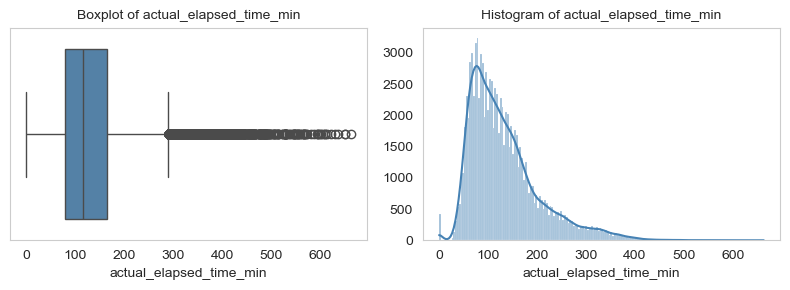

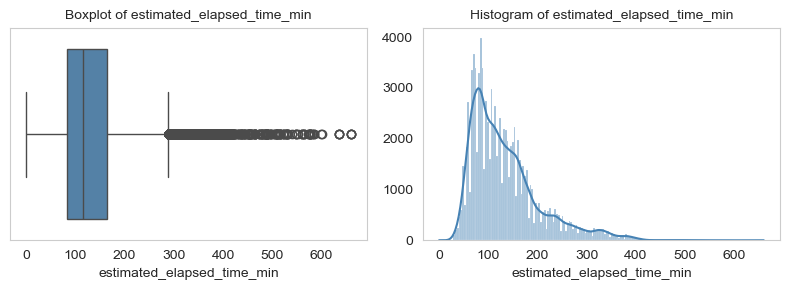

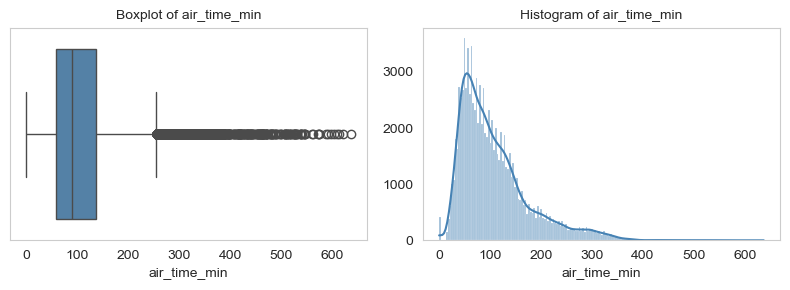

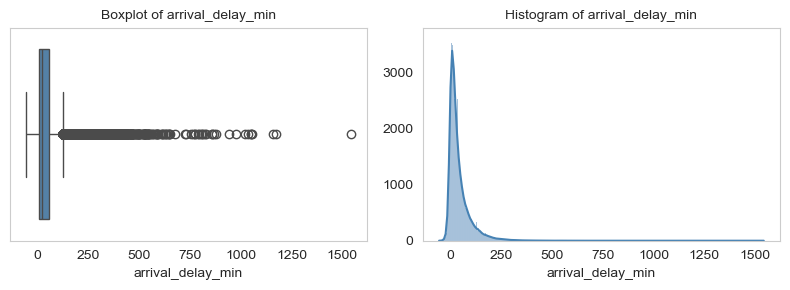

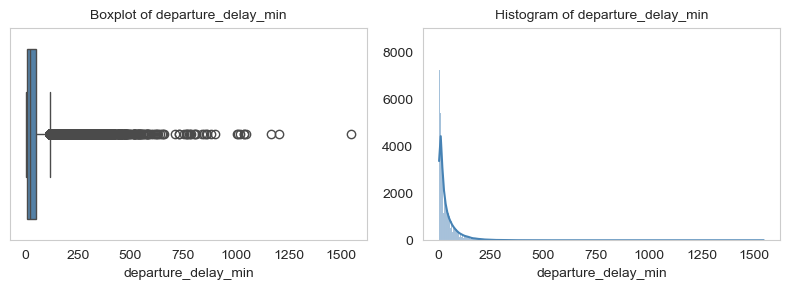

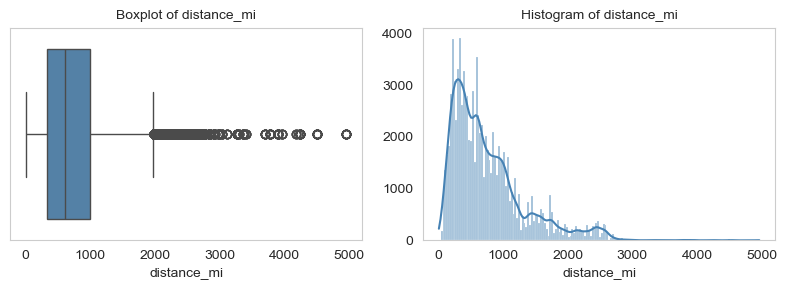

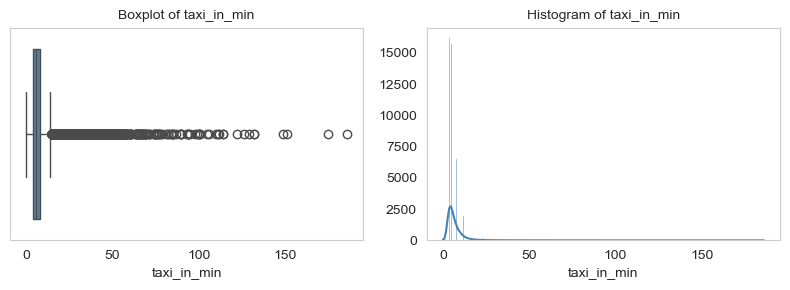

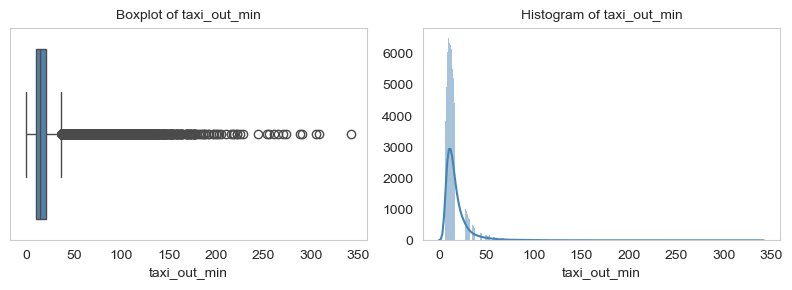

In [52]:
fig_num = 1
interested_num_col =['actual_elapsed_time_min', 
                'estimated_elapsed_time_min', 'air_time_min', 'arrival_delay_min', 
                'departure_delay_min', 'distance_mi', 'taxi_in_min', 
                'taxi_out_min']
for col in df.select_dtypes(include=[np.number]).columns:
    if col in interested_num_col:
        hist_box_plot(df,col, fig_num)
        fig_num = fig_num + 1

### Univariate Distribution of Categorical Features

#### By Carrier 

In [21]:
sns.set(style="whitegrid", context='talk')  # Consolidated style settings
sns.set_context(rc={'patch.linewidth': 0.0})  # Custom context

# Creating figure
fig, ax = plt.subplots(figsize=(10, 3))

# Sorting the data in ascending order based on the count of 'carrier_code'
carrier_order = df['carrier_code'].value_counts(ascending=False).index

# Generating count plot
sns.countplot(x=df['carrier_code'], data=df, color='steelblue', ax=ax, order = carrier_order)

# Adding title if provided
ax.set_title('Number of Flights by carriers_code', fontsize=14)
ax.set_xlabel('carrier_code', fontsize =12)
ax.set_ylabel('Flights', fontsize =12)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

# Show the plot
plt.show()

NameError: name 'sns' is not defined

#### By Status

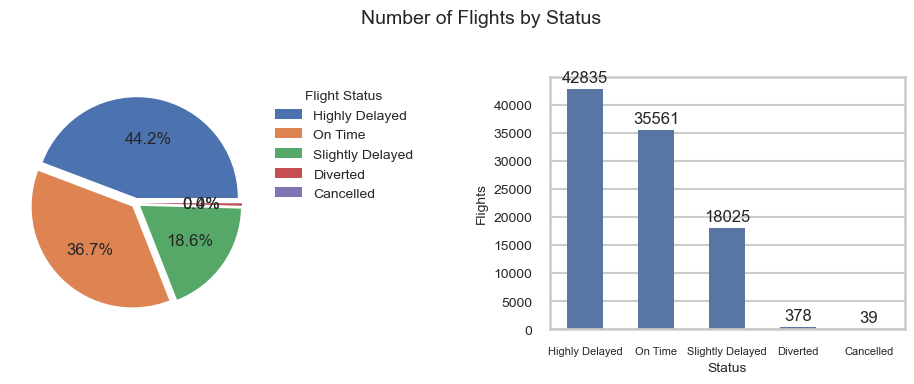

In [57]:
status_labels = {
    0: 'On Time',# less than 15 mins
    1: 'Slightly Delayed', # less than 30 mins
    2: 'Highly Delayed', # more than or equal to 30 mins
    3: 'Diverted',
    4: 'Cancelled'
}

# Create the subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart of cancellation codes without labels, but adding a legend
df['status'].value_counts().plot.pie(
    explode=[0.05] * df['status'].nunique(),
    autopct= '%1.1f%%',
    textprops={'fontsize': 12},
    labels=None,
    ax=ax[0]
)
ax[0].set_ylabel('')

# Add legend for the pie chart
ax[0].legend(
    labels=[status_labels[key] for key in df['status'].value_counts().index], 
    fontsize= 10,
    loc="best",
    bbox_to_anchor=(1, 1),
    title="Flight Status",
    title_fontsize= 10
)

# Count plot of cancellation codes
bars = sns.countplot(x='status', 
              order=df['status'].value_counts().index, 
              data=df,
              ax=ax[1],
              width=0.5 
             )
# Add count labels on top of each bar
bars.set_xlabel('Status', fontsize=10)
bars.set_ylabel('Flights', fontsize=10)
bars.tick_params(axis='y', labelsize=10)
bars.tick_params(axis='x', labelsize=8)

for bar in bars.patches:
    bars.annotate(
        format(int(bar.get_height())),  # Format as an integer
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),  # Position at the top of the bar
        ha='center', va='center', size=12, xytext=(0, 8), textcoords='offset points'
    )

# Update x-tick labels with status descriptions
bars.set_xticklabels([status_labels[float(x.get_text())] for x in bars.get_xticklabels()])



fig.suptitle('Number of Flights by Status', fontsize=14, x=0.55)

# Show the plot
plt.tight_layout()
plt.show()


- Delays: A large proportion of flights face delays (both highly delayed and slightly delayed combined make up 62.8% of all flights). This could indicate operational issues, weather-related challenges, or other common factors causing delays.
- On-Time Performance: Though on-time flights make up a significant 36.7%, the fact that most flights are delayed highlights room for improvement in scheduling, efficiency, or external factors like air traffic control.
- Low Diversion and Cancellation Rates: The very low number of diverted and canceled flights suggests that despite delays, most flights are completed as planned.

Overall, the data points to delays being a major issue, with nearly two-thirds of flights not arriving on time.

#### By Departure Date

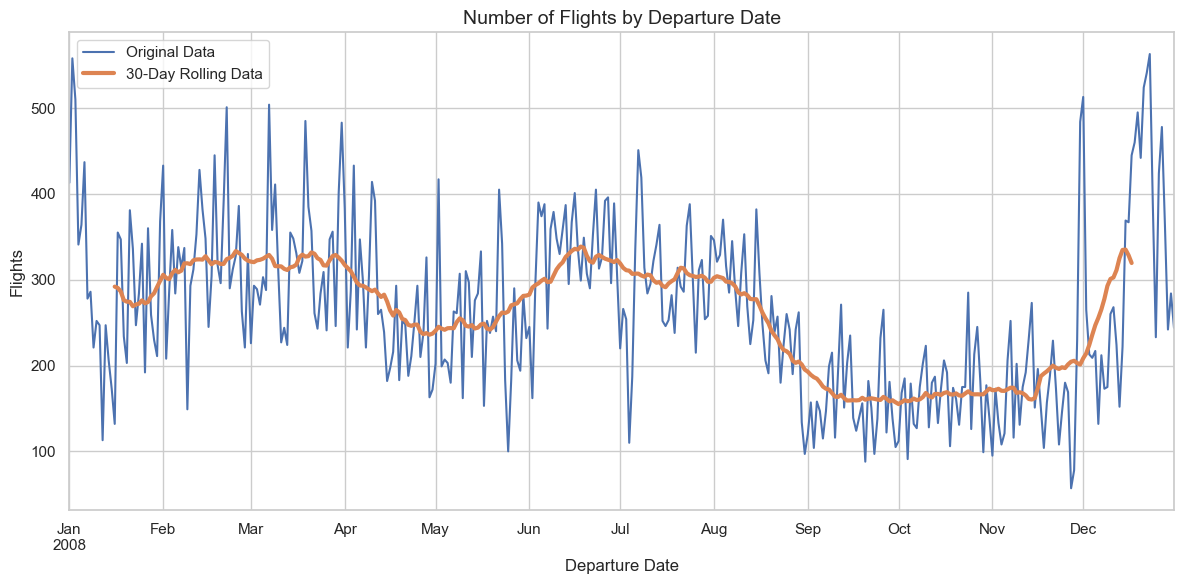

In [59]:
import matplotlib.dates as mdates

# Group by 'departure_date' and 'status', then count occurrences
flightbyDate = df.groupby(['departure_date']).size()

sns.set_theme(style="whitegrid")

# Plot the grouped data
ax = flightbyDate.plot(kind='line', figsize=(10, 4), label='Original Data')

# Calculate the rolling mean (trend line)
rolling_data = flightbyDate.rolling(window=30, center=True).mean()  # 30-day rolling average

# Plot the rolling mean (trend line) with stronger colors
rolling_data.plot(ax=ax, kind='line', linewidth=3, figsize=(12, 6) , label='30-Day Rolling Data')


# Set plot labels and title
ax.set_xlabel('Departure Date')
ax.set_ylabel('Flights')
ax.set_title('Number of Flights by Departure Date', fontsize =14)

# Add a custom legend for original data and rolling data
plt.legend(loc='best')

# Add gridlines for easier reading
plt.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


Seasonality: There appears to be a seasonal pattern, with flight counts peaking in early January and again toward the end of the year, which could correspond to holiday travel seasons. The summer months show a general decrease in flights.
- Early Year (January to March): Flight activity seems to stabilize after a peak in January, with a general downward trend until March.
- Mid-Year (March to September): The number of flights fluctuates around the 300-flight mark, with a slight decline during the summer months.
- Late Year (October to December): Flight activity shows a strong upward trend, especially in November and December, indicating a possible holiday or end-of-year travel surge.

### Analysis on Delayed Flights

#### Arrival delay time (in minutes) by month

In [62]:
# define dataframe only contains delayed flights where status = 1 (sightly delayed) or 2 (highly delayed)
delayedFlight = df[df['status'].isin([1, 2])]

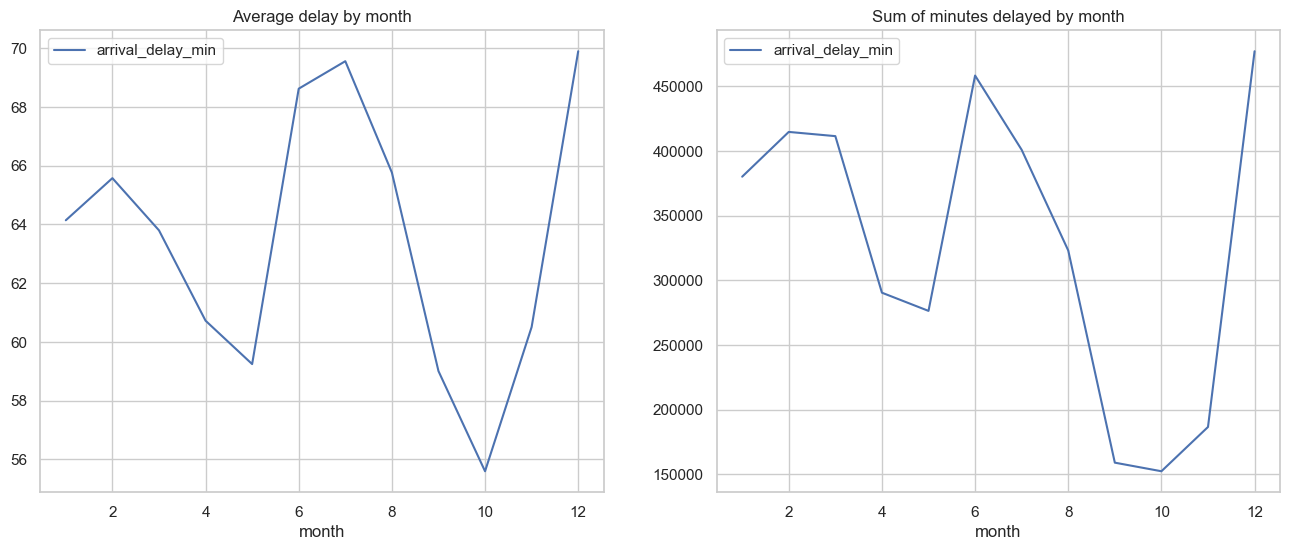

In [63]:
fig,ax=plt.subplots(1,2,figsize=(16,6))
delayedFlight[['month','arrival_delay_min']].groupby(['month']).mean().plot(ax=ax[0])
ax[0].set_title('Average delay by month')
delayedFlight[['month','arrival_delay_min']].groupby(['month']).sum().plot(ax=ax[1])
ax[1].set_title('Sum of minutes delayed by month')
plt.show()

- **June and December** are the most delayed months in both average and total delay minutes, which is expected given the high travel demand during the summer vacation and winter holiday seasons.
- **August to September** experience the lowest delays, both in average and total minutes, likely due to lower travel demand and more favorable weather conditions.
- **The spring months (March to May)** are relatively stable, showing moderate delays, but not as severe as June or December.

The delay patterns seem reflect typical U.S. travel seasons, with spikes in high-demand periods (summer and holiday seasons) and reductions during off-peak periods (fall and late summer).

#### Correlation matrix of Delayed Flight

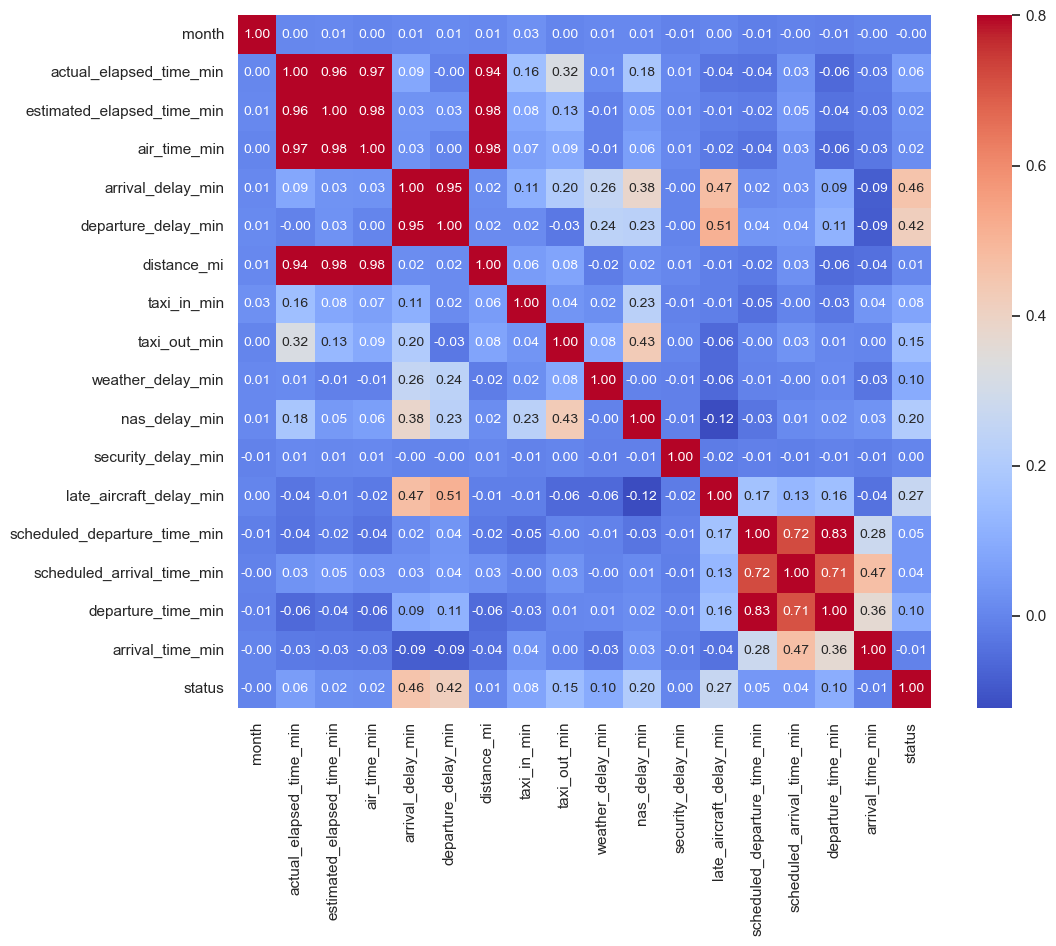

In [65]:
numerical_cols = delayedFlight.select_dtypes(include='number')

# Exclude columns containing 'carrier', 'cancel', 'diverted', or 'day'
delay_num_cols = numerical_cols.loc[:, ~numerical_cols.columns.str.contains('carrier|cancel|diverted|day|year')]

delaycorrmat = delay_num_cols.corr()

# Set the size of the plot
f, ax = plt.subplots(figsize=(12, 9))

# Plot heatmap with more customization
sns.heatmap(delaycorrmat, vmax=.8, cmap="coolwarm", square=True, annot= True, annot_kws={"size":10}, fmt='.2f',)
sns.set(font_scale=1.25)

# Show the plot
plt.show()

#### Total Delay in minutes by delay reason

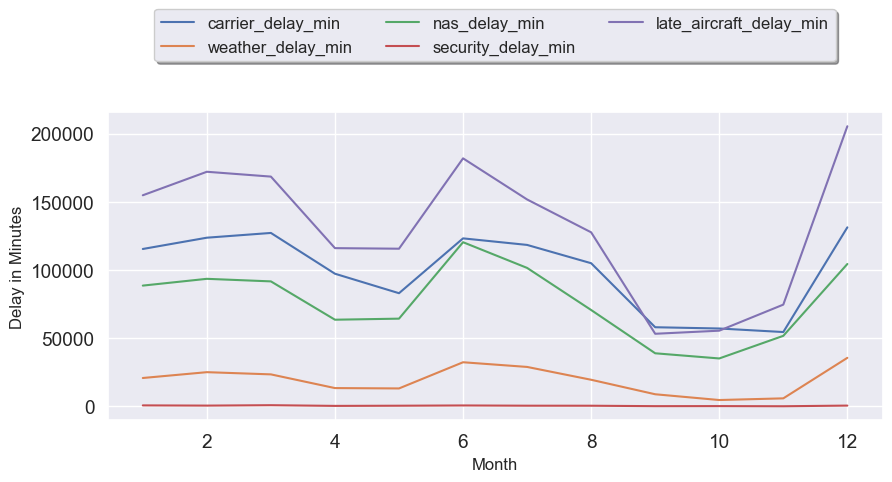

In [66]:
delaybyReason = delayedFlight.filter(['month', 'carrier_delay_min', 'weather_delay_min', 'nas_delay_min', 'security_delay_min', 'late_aircraft_delay_min'], axis=1)

# Group by 'month' and sum the delay columns
delaybyReason_sum = delaybyReason.groupby('month')[['carrier_delay_min', 'weather_delay_min', 'nas_delay_min', 'security_delay_min', 'late_aircraft_delay_min']].sum()

# Plot the summed delay data
ax = delaybyReason_sum.plot(figsize = (10, 4))
ax.set_xlabel('Month', fontsize = 12)
ax.set_ylabel('Delay in Minutes', fontsize = 12)

# Adjust legend position and appearance
ax.legend(loc='center', bbox_to_anchor=(0.5, 1.25), ncol=3, shadow=True, fontsize = 12)

# Show the plot
plt.show()

## 4) Data Modeling

After exploring the data, it became clear that several features correlate with, or may even contribute to, the occurrence of delays, particularly the 'arrival_delay_time'. However, using all the features, especially those related to the arrival phase, to predict arrival delay time would be impractical. Therefore, I have focused on using only the features available up until the plane has taxied off from the departure airport. This ensures the model can make predictions based on information known before the flight departs.

In [69]:
carrier_columns = df.filter(like='carrier_code_').columns.tolist()

departed_features = ['scheduled_departure_time_min', 'scheduled_arrival_time_min', 'distance_mi', 
                    'day_of_week', 'month', 'departure_time_min', 'departure_delay_min', 'taxi_out_min' ] + carrier_columns

### 4.1) Prediction of Arrival Delay time (min) after departed

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, r2_score

# Define the departure features list as dependent X values and "arrival_delay_min" as independent Y values
X = df[departed_features] # predictors 
y = df['arrival_delay_min']

# Split the dataset, 80% for training and 20% for testing with random_state as my strudent ID.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=46800883)

In [72]:
# Train the logistic regression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

LinearRegression()

In [73]:
# Make prediction on the testing set
y_pred = linreg.predict(X_test)

# Calculate regression metrics
mse_test = mean_squared_error(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

# Output the results
print(f"Test Mean Squared Error: {mse_test:.4f}")
print(f"Test Mean Absolute Error: {mae_test:.4f}")
print(f"Test R-squared: {r2_test:.4f}")

Test Mean Squared Error: 173.4801
Test Mean Absolute Error: 8.5070
Test R-squared: 0.9471


#### Conclusion for the model result:
**Performance:**
- The R-squared value of 0.9471 indicates that the model explains 94.71% of the variance in arrival delay time. This is a strong result, showing that the chosen departure features have a significant impact on predicting the arrival delay.
- The Mean Squared Error (MSE) of 173.48 and the Mean Absolute Error (MAE) of 8.51 suggest that the model’s predictions are fairly close to the actual delay times. These errors represent the average differences between the predicted and actual delay times in minutes.

**Interpretation:**
- The high R-squared value suggests that the selected predictors (features available before the plane has taken off) are effective in forecasting arrival delays.
- The relatively low MSE and MAE values indicate that the model is fairly accurate in predicting the arrival delay times, making it useful for operational decision-making and planning purposes.

**Conclusion:**
- The linear regression model performs well for predicting arrival delay times based on departure-related features, demonstrating that these features are reliable predictors.
- This model could be used by airlines or airports to estimate delays in real-time, potentially improving resource management and passenger communication strategies.

### 4.2) Prediction of Flight Status after departed by KNN Classifier

Now, I aim to predict the final status of the flight—whether it is on-time, slightly delayed, highly delayed, canceled, or diverted. While it can be assumed that predicting cancellations may not be feasible due to the lack of crucial data such as weather conditions and aircraft or airport maintenance information (which are directly linked to cancellations), the other statuses seem more predictable. To begin, I used the **K-Nearest Neighbors (KNN) classifier** to model and predict the flight status.

In [77]:
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df[departed_features]
y = df['status']  # Target column

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=46800883)

# Standardize the features before apply to KNN
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [78]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid for K
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15]}

# Initialize GridSearchCV with KNN and the parameter grid
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')

# Fit the model to find the best K
grid_search.fit(X_train, y_train)

# Get the best K value
best_k = grid_search.best_params_['n_neighbors']
print(f"Best K value: {best_k}")

Best K value: 15


In [79]:
# Initialize the KNN classifier (you can start with k=5)
knn = KNeighborsClassifier(n_neighbors=best_k)

# Train the model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=15)

In [80]:
# Make predictions on the testing set
y_pred = knn.predict(X_test)

In [81]:
from sklearn.metrics import accuracy_score, f1_score

# Calculate accuracy, F1-score, precision, and recall for multi-class
accuracy_test = accuracy_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred, average='weighted')  # 'weighted' handles class imbalance

# Output the results
print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test F1-Score: {f1_test:.4f}")

Test Accuracy: 0.7174
Test F1-Score: 0.6883


#### Conclusion for the model result
The KNN classifier, after hyperparameter tuning, achieved an accuracy of 71.74% and a balanced F1-score of 0.6883. These results suggest that the model performs reasonably well in predicting flight status (on-time, delayed, canceled, or diverted). However, there is room for improvement, since the model faces limitations in accurately predicting more complex outcomes such as cancellations and diversions.  This is largely due to the absence of crucial features, such as weather conditions, aircraft maintenance records, and airport or air traffic information, which are key factors influencing cancellations and diversions. As a result, while the model can provide useful insights into delay patterns, its ability to predict cancellations or diversions remains limited. For a more robust prediction of such outcomes, additional data would be necessary.

### 4.3) Prediction of Flight Status after departed by MLP Classification

I will also apply a neural network, specifically the MLPClassifier, to determine if it can improve the accuracy of the model compared to the KNN classifier.

In [85]:
from sklearn.neural_network import MLPClassifier

# Initialize the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(128, 64),  # Two hidden layers with 128 and 64 neurons
                    activation='logistic',        # Activation function, logistics for multiclass 
                    solver='adam',                # Optimization algorithm, adam for large dataset
                    max_iter=300,                 # Maximum number of iterations
                    random_state=46800883,        # For reproducibility
                    early_stopping=True,          # Stop early if validation score doesn't improve
                    validation_fraction=0.2)      # Use 20% of the training data for validation

In [86]:
# Train the MLPClassifier
mlp.fit(X_train, y_train)

MLPClassifier(activation='logistic', early_stopping=True,
              hidden_layer_sizes=(128, 64), max_iter=300, random_state=46800883,
              validation_fraction=0.2)

In [87]:
# Make predictions on the test set
y_pred_mlp = mlp.predict(X_test)

In [88]:
# Calculate evaluation metrics
accuracy_test = accuracy_score(y_test, y_pred_mlp)
f1_test = f1_score(y_test, y_pred_mlp, average='weighted')

# Output the results
print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test F1-Score: {f1_test:.4f}")

Test Accuracy: 0.8045
Test F1-Score: 0.7955


#### Conclusion for the model result
The MLPClassifier did a better job at predicting flight status compared to the KNN model. It achieved an accuracy of 80.45%, which means it correctly predicted the flight status 80% of the time, an improvement over the KNN model's 71%. The F1-score, which measures how well the model balances precision and recall, was also strong at 0.7955.
In terms, the MLPClassifier was able to learn more from the data and make more accurate predictions about whether a flight would be on time, delayed, canceled, or diverted, making it a better choice for this task than the previous model.

### Conclusion

In this study, I used features like scheduled departure and arrival times, distance, day of the week, month, departure delays, taxi-out time, and carrier information to try and predict flight delays and statuses. The Linear Regression model worked really well for predicting arrival delay times, with an R-squared value of 94.71%. This shows that departure-related factors, like how late the flight leaves and how long it takes to taxi out, are important in determining overall delay times.

For predicting flight status, I started by using the K-Nearest Neighbors (KNN) classifier. KNN had an accuracy of 71.74%, but its performance was limited because it couldn’t handle the complex, non-linear relationships between the features. While it worked okay as a basic model, the lower accuracy suggested that more advanced methods would likely do better. Since KNN relies on comparing nearby data points without really understanding deeper patterns, it struggled to predict more complicated outcomes, like cancellations or diversions.

To improve this, I applied the MLPClassifier (a neural network) to see if it would boost accuracy. The MLP model did better than KNN, with an accuracy of 80.45%, thanks to its ability to recognize more complex patterns in the data. However, even with the improvement, both models were held back by missing critical data, such as weather conditions and maintenance issues, which are often key factors in predicting cancellations and diversions.

In conclusion, while the KNN model was a good starting point for classifying flight statuses, the MLPClassifier performed better by modeling more complex relationships. Still, both models were limited because they didn’t have important external factors like weather and maintenance data, which are needed to make accurate predictions for cancelled and diverted flights.